### Exploratory Data Analysis for Research Question 3 
- To what extent are demographic characteristics particularly gender, associated with financial inclusion in Thailand, and have these disparities changed between 2021 and 2024?

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

rq3 = pd.read_csv("data_cleaned.csv")

In [3]:
rq3.head(5)

,wage_payment_method,no_account_family_member,debit_card_ownership,ever_had_mobile_money_account,survey_year,ever_had_bank_account,...,received_transfers,no_account_insufficient_funds,codes_found,gender,age_group,education_original
0,2.0,NaN,2.0,2.0,2021,NaN,...,1.0,NaN,False,Female,23_29,3.0
1,2.0,NaN,1.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0
2,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
3,NaN,NaN,NaN,2.0,2021,NaN,...,1.0,NaN,False,Female,40_49,3.0
4,NaN,NaN,2.0,1.0,2021,NaN,...,1.0,NaN,False,Male,30_39,3.0


In [5]:
rq3.columns.tolist()

['wage_payment_method',
 'no_account_family_member',
 'debit_card_ownership',
 'ever_had_mobile_money_account',
 'survey_year',
 'ever_had_bank_account',
 'no_account_documentation',
 'borrowed_money',
 'saved_mobile_money',
 'female',
 'account_ownership',
 'credit_card_ownership',
 'received_goverment_transfer',
 'wages_bank_account',
 'mobile_money_transaction',
 'agriculture_payment_method',
 'mobile_money_activity',
 'no_account_distance',
 'age',
 'saved_bank',
 'education_level',
 'received_wages',
 'utility_payment',
 'any_digital_payment',
 'account_transaction_activity',
 'no_mobile_agents_far',
 'emergency_funds',
 'no_account_too_expensive',
 'sent_domestic_remittance_account',
 'merchantpay_dig',
 'store_money_account',
 'income_quintile',
 'utility_payment_cash',
 'agriculture_payment_account',
 'borrowed_from_family_friends',
 'financial_health_indicator',
 'borrowed_from_formal_bank',
 'mobile_money_send_recieve',
 'high_withdrawal_fee_wages',
 'received_acc_balance_inf

### Financial Inclusion Dimension

### Demographics & socioeconomics indicators

In [11]:
demographics = rq3[["age", "gender", "income_quintile", "education_level", "survey_year", "employment_status"]]

In [13]:
demographics.head()

,age,gender,income_quintile,education_level,survey_year,employment_status
0,27.0,Female,Q4,3.0,2021,1.0
1,30.0,Male,Q4,3.0,2021,1.0
2,45.0,Female,Q4,3.0,2021,1.0
3,45.0,Female,Q1 Lowest,3.0,2021,1.0
4,39.0,Male,Q4,3.0,2021,1.0


In [14]:
demographics["gender"].value_counts(normalize=True)*100

gender
Female    54.586019
Male      45.413981
Name: proportion, dtype: float64

In [15]:
demographics["income_quintile"].value_counts(normalize=True)*100

income_quintile
Q5 Highest    26.623699
Q4            23.153198
Q3            17.600397
Q1 Lowest     16.955875
Q2            15.666832
Name: proportion, dtype: float64

### Age Distribution

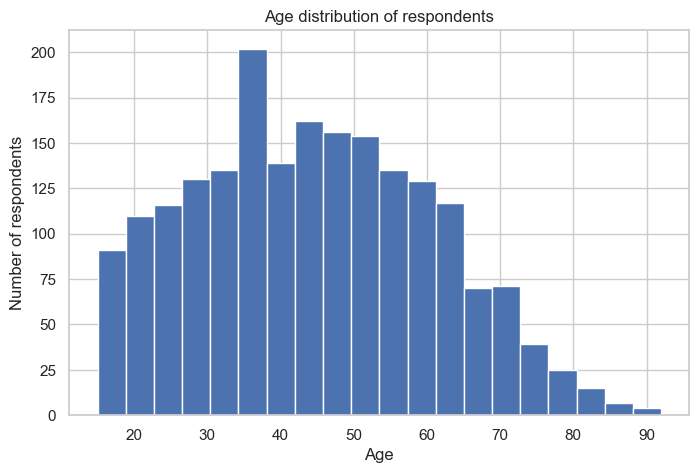

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(demographics["age"].dropna(),bins=20)
plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.title("Age distribution of respondents")

plt.show()

### Gender Distribution

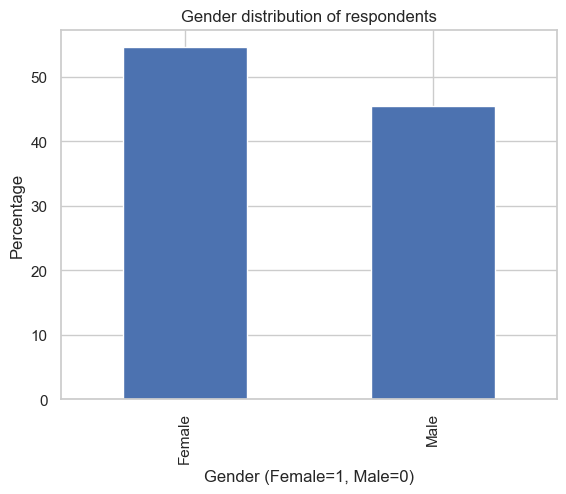

In [17]:
gender_pct = (demographics["gender"].value_counts(normalize=True).mul(100))
gender_pct.plot(kind="bar")
plt.xlabel("Gender (Female=1, Male=0)")
plt.ylabel("Percentage")
plt.title("Gender distribution of respondents")

plt.show()

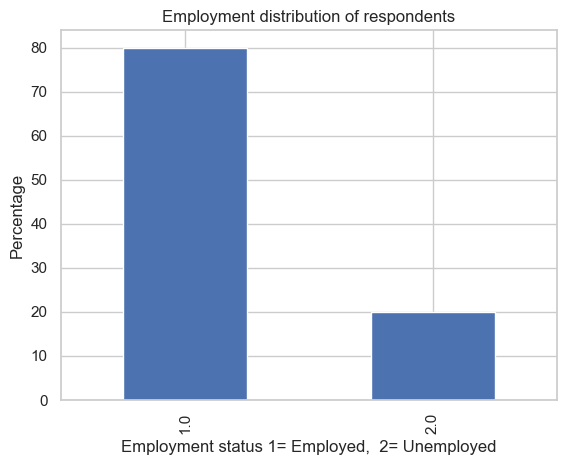

In [103]:
# Employment distribution of respondents
employment_pct = (demographics["employment_status"].value_counts(normalize=True).mul(100))
employment_pct.plot(kind="bar")
plt.xlabel("Employment status 1= Employed,  2= Unemployed")
plt.ylabel("Percentage")
plt.title("Employment distribution of respondents")

plt.show()

### Account Usage

In [29]:
rq3["account_usage"] = rq3["account_usage"].astype("Int64") 

In [30]:
df_health = rq3[rq3["account_usage"].isin([1, 2, 3, 4, 5, 6])].copy()

In [31]:
print(rq3["account_usage"].value_counts(dropna=False))

account_usage
1       1130
2        477
<NA>     163
3        155
4         63
6         19
5         10
Name: count, dtype: Int64


In [ ]:
account_usage_labels = {
    1: "Weekly deposit",
    2: "Monthly deposit",
    3: "Less than monthly deposit",
    4: "Never deposited",
    5: "Don't know",
    6: "Refused"
}

# account_usage is only asked of account owners, so non-owners are NA 
rq3["financial_health_indicator"] = (
    rq3["account_usage"]
    .map(account_usage_labels)
    .fillna("Not applicable (no account)")
)

print(rq3["financial_health_indicator"].value_counts(dropna=False))

financial_health_indicator
Weekly deposit                 1130
Monthly deposit                 477
Not applicable (no account)     163
Less than monthly deposit       155
Never deposited                  63
Refused                          19
Don't know                       10
Name: count, dtype: int64


In [45]:
financial_vars = [
    "account_ownership",
    "financial_instituion_account",
    "mobile_money_account",
    "any_digital_payment",
    "saved_money",
    "borrowed_money"
]

In [46]:
for col in financial_vars:
    print(
        f"\n{col}")
    print(rq3[col].value_counts(normalize=True).mul(100))


account_ownership
account_ownership
1    94.843827
0     5.156173
Name: proportion, dtype: float64

financial_instituion_account
financial_instituion_account
1    94.199306
0     5.800694
Name: proportion, dtype: float64

mobile_money_account
mobile_money_account
1.0    51.611304
0.0    48.388696
Name: proportion, dtype: float64

any_digital_payment
any_digital_payment
1.0    88.844819
0.0    11.155181
Name: proportion, dtype: float64

saved_money
saved_money
1.0    68.071393
0.0    31.928607
Name: proportion, dtype: float64

borrowed_money
borrowed_money
1.0    54.090233
0.0    45.909767
Name: proportion, dtype: float64


In [47]:
inclusion_rates = (rq3[financial_vars].mean().sort_values(ascending=False).mul(100))

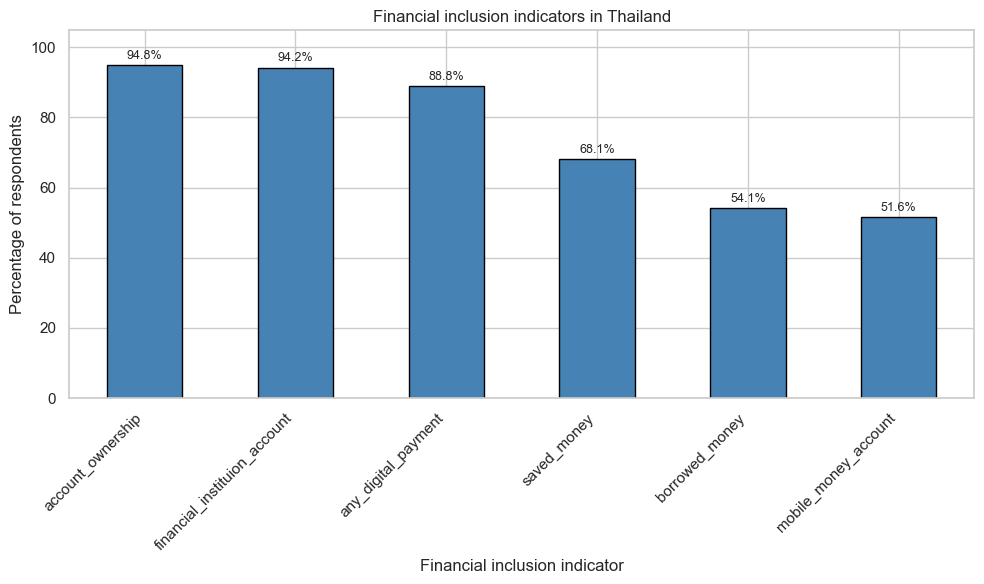

In [48]:
ax = inclusion_rates.plot(kind="bar", figsize=(10, 6), color="steelblue", edgecolor="black")

for bar, value in zip(ax.patches, inclusion_rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.ylabel("Percentage of respondents")
plt.xlabel("Financial inclusion indicator")
plt.title("Financial inclusion indicators in Thailand")
plt.ylim(0, inclusion_rates.max() + 10)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

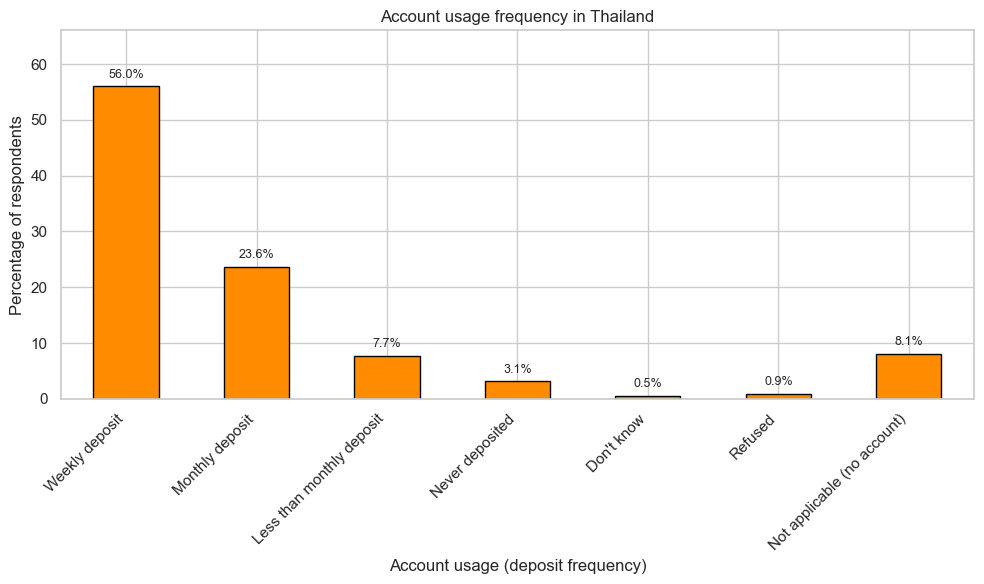

In [49]:
## Account usage frequency (categorical, not a binary rate)
usage_order = [
    "Weekly deposit",
    "Monthly deposit",
    "Less than monthly deposit",
    "Never deposited",
    "Don't know",
    "Refused",
    "Not applicable (no account)"
]
usage_pct = (
    rq3["financial_health_indicator"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(usage_order)
)

ax = usage_pct.plot(kind="bar", figsize=(10, 6), color="darkorange", edgecolor="black")

for bar, value in zip(ax.patches, usage_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{value:.1f}%", ha="center", va="bottom", fontsize=9)

plt.ylabel("Percentage of respondents")
plt.xlabel("Account usage (deposit frequency)")
plt.title("Account usage frequency in Thailand")
plt.ylim(0, usage_pct.max() + 10)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


        account_ownership  financial_instituion_account  mobile_money_account  \
gender                                                                          
Female          94.277929                     93.642144             49.137148   
Male            95.524017                     94.868996             54.585153   

        any_digital_payment  saved_money  borrowed_money  
gender                                                    
Female            87.829246    66.303361       53.678474  
Male              90.065502    70.196507       54.585153  


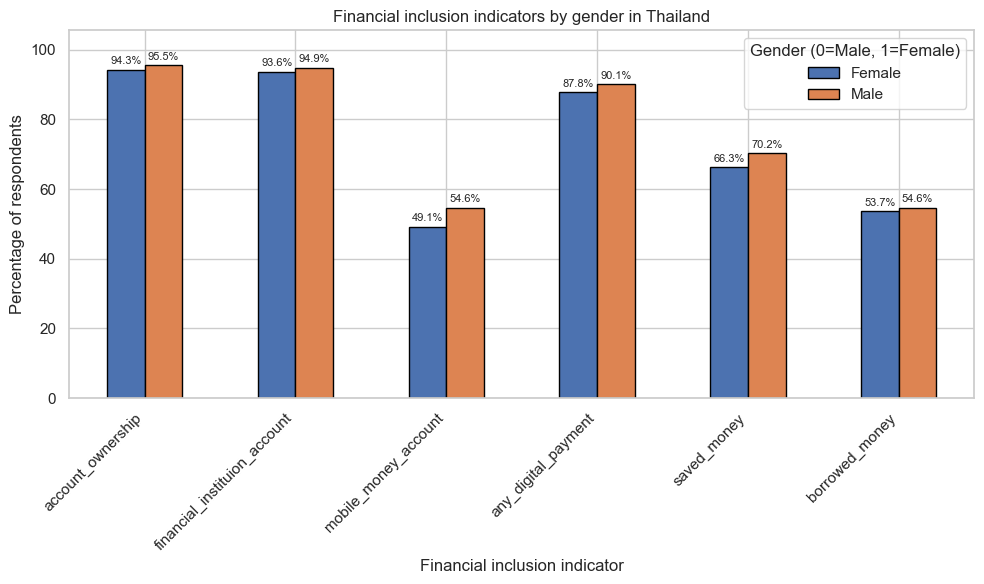

In [ ]:
## Gender inclusion
gender_inclusion = (rq3.groupby("gender")[financial_vars].mean().mul(100))
print(gender_inclusion)

ax = gender_inclusion.T.plot(kind="bar", figsize=(10, 6), edgecolor="black")

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.ylabel("Percentage of respondents")
plt.xlabel("Financial inclusion indicator")
plt.title("Financial inclusion indicators by gender in Thailand")
plt.ylim(0, gender_inclusion.values.max() + 10)
plt.legend(title="Gender")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

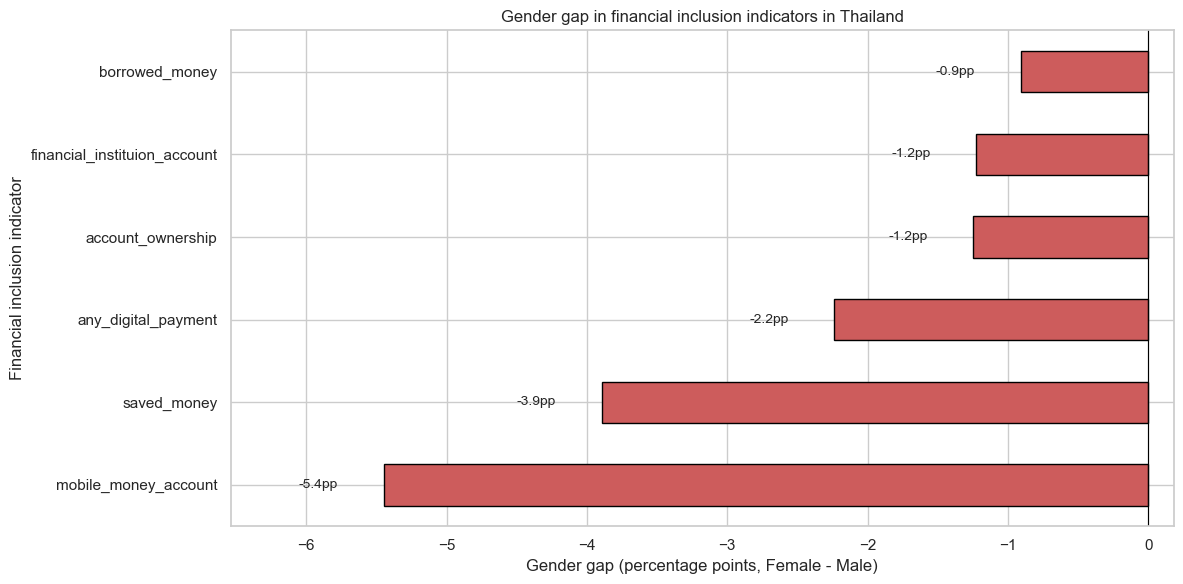

In [57]:
## Gender gap rate (Female % - Male %) per financial inclusion indicator
gender_gap = (gender_inclusion.loc["Female"] - gender_inclusion.loc["Male"]).sort_values()

colors = ["seagreen" if v >= 0 else "indianred" for v in gender_gap]
ax = gender_gap.plot(kind="barh", figsize=(12, 6), color=colors, edgecolor="black")

buffer = max(gender_gap.abs().max() * 0.2, 1)
ax.set_xlim(gender_gap.min() - buffer, gender_gap.max() + buffer)
ax.margins(y=0.15)

for bar, value in zip(ax.patches, gender_gap):
    offset = buffer * 0.3 if value >= 0 else -buffer * 0.3
    ha = "left" if value >= 0 else "right"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}pp", ha=ha, va="center", fontsize=10)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Gender gap (percentage points, Female - Male)")
plt.ylabel("Financial inclusion indicator")
plt.title("Gender gap in financial inclusion indicators in Thailand")

plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()

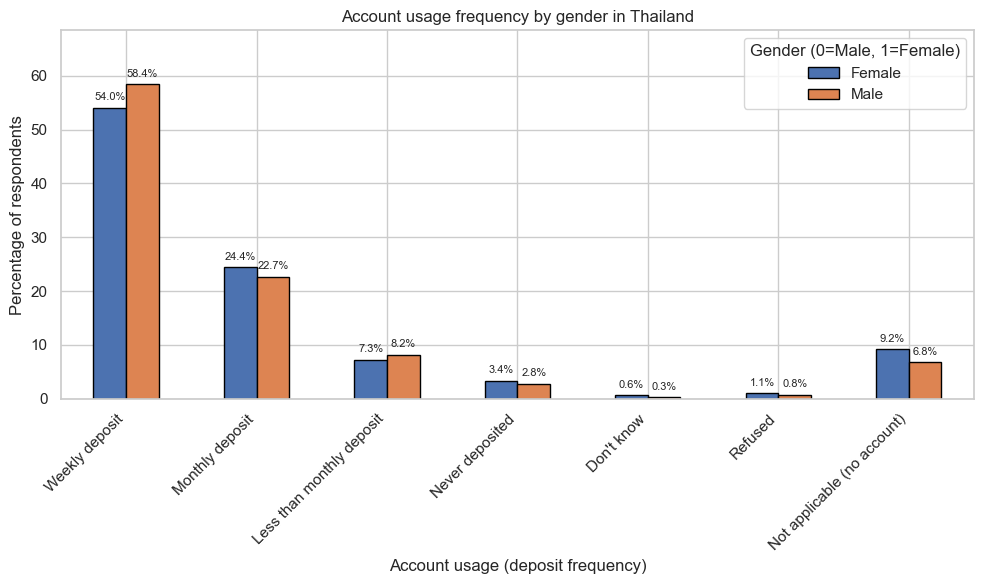

In [ ]:
## Account usage frequency by gender (categorical -> crosstab, not mean)
usage_by_gender = (
    pd.crosstab(rq3["gender"], rq3["financial_health_indicator"], normalize="index")
    .mul(100)
    .reindex(columns=usage_order)
)

ax = usage_by_gender.T.plot(kind="bar", figsize=(10, 6), edgecolor="black")

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.ylabel("Percentage of respondents")
plt.xlabel("Account usage (deposit frequency)")
plt.title("Account usage frequency by gender in Thailand")
plt.ylim(0, usage_by_gender.values.max() + 10)
plt.legend(title="Gender")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


             account_ownership  financial_instituion_account  \
survey_year                                                    
2021                 98.033432                     97.345133   
2024                 91.600000                     91.000000   

             mobile_money_account  any_digital_payment  saved_money  \
survey_year                                                           
2021                    69.911504            96.361849    78.662734   
2024                    33.000000            81.200000    57.300000   

             borrowed_money  
survey_year                  
2021              64.405113  
2024              43.600000  


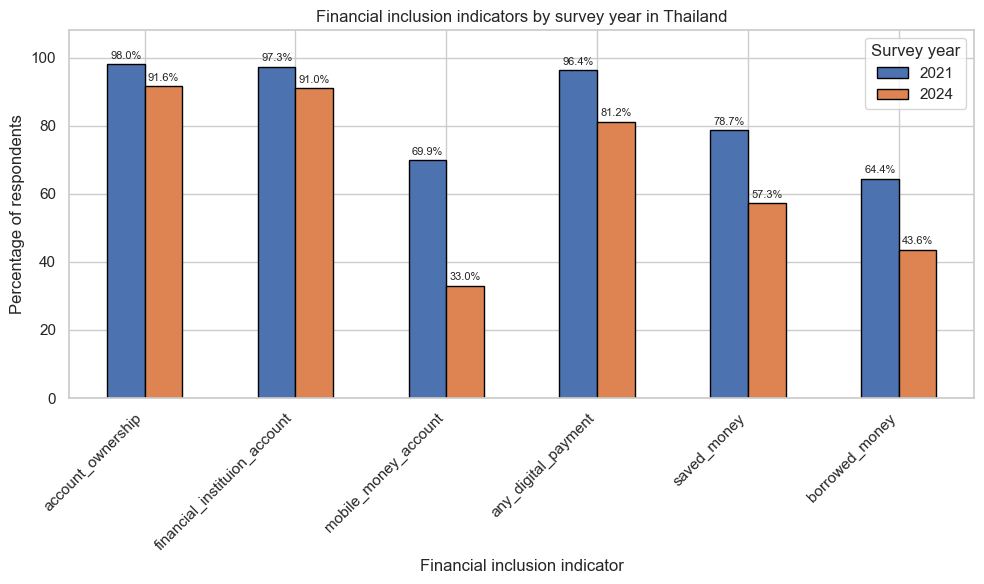

In [58]:
## Financial inclusion by survey year (2021 vs 2024)
year_inclusion = (rq3.groupby("survey_year")[financial_vars].mean().mul(100))
print(year_inclusion)

ax = year_inclusion.T.plot(kind="bar", figsize=(10, 6), edgecolor="black")

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)

plt.ylabel("Percentage of respondents")
plt.xlabel("Financial inclusion indicator")
plt.title("Financial inclusion indicators by survey year in Thailand")
plt.ylim(0, year_inclusion.values.max() + 10)
plt.legend(title="Survey year")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

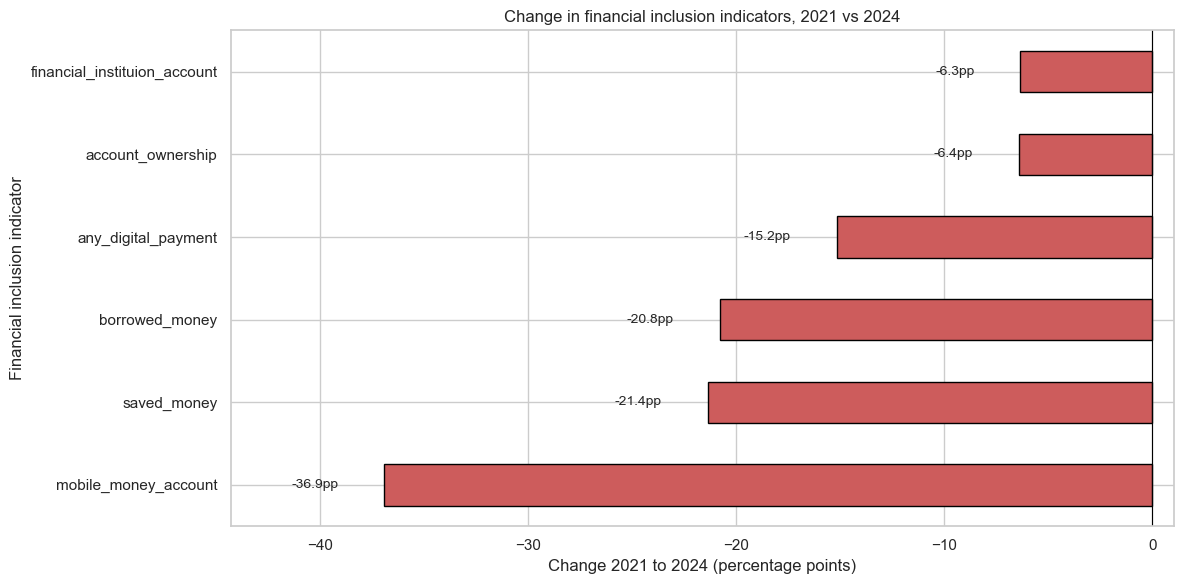

In [59]:
## Change over time (2024 - 2021) per financial inclusion indicator
year_gap = (year_inclusion.loc[2024] - year_inclusion.loc[2021]).sort_values()

colors = ["seagreen" if v >= 0 else "indianred" for v in year_gap]
ax = year_gap.plot(kind="barh", figsize=(12, 6), color=colors, edgecolor="black")

buffer = max(year_gap.abs().max() * 0.2, 1)
ax.set_xlim(year_gap.min() - buffer, year_gap.max() + buffer)
ax.margins(y=0.15)

for bar, value in zip(ax.patches, year_gap):
    offset = buffer * 0.3 if value >= 0 else -buffer * 0.3
    ha = "left" if value >= 0 else "right"
    ax.text(bar.get_width() + offset, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}pp", ha=ha, va="center", fontsize=10)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Change 2021 to 2024 (percentage points)")
plt.ylabel("Financial inclusion indicator")
plt.title("Change in financial inclusion indicators, 2021 vs 2024")

plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()


                    account_ownership  financial_instituion_account  \
survey_year gender                                                    
2021        Female          97.286822                     97.093023   
            Male            98.802395                     97.604790   
2024        Female          91.623932                     90.598291   
            Male            91.566265                     91.566265   

                    mobile_money_account  any_digital_payment  saved_money  \
survey_year gender                                                           
2021        Female             70.155039            95.542636    78.294574   
            Male               69.660679            97.205589    79.041916   
2024        Female             30.598291            81.025641    55.726496   
            Male               36.385542            81.445783    59.518072   

                    borrowed_money  
survey_year gender                  
2021        Female       63.17

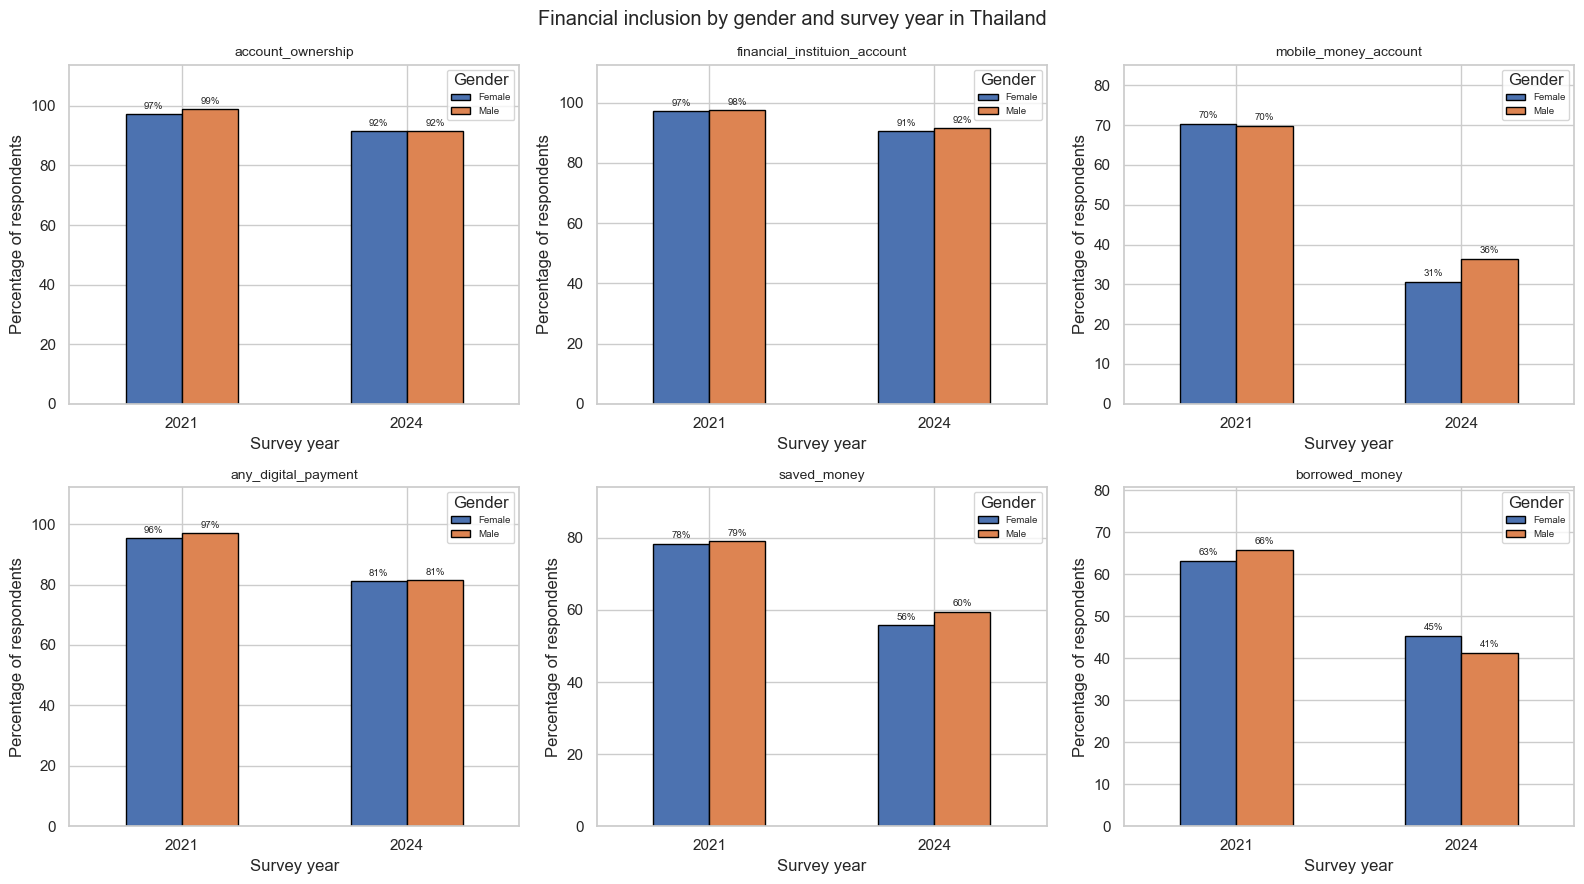

In [60]:
## Financial inclusion by gender and survey year combined
gender_year_inclusion = (rq3.groupby(["survey_year", "gender"])[financial_vars].mean().mul(100))
print(gender_year_inclusion)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, financial_vars):
    data = gender_year_inclusion[col].unstack("gender")
    data.plot(kind="bar", ax=ax, edgecolor="black")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=7)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Percentage of respondents")
    ax.set_xlabel("Survey year")
    ax.set_ylim(0, data.values.max() + 15)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Gender", fontsize=7)

plt.suptitle("Financial inclusion by gender and survey year in Thailand")
plt.tight_layout()
plt.show()


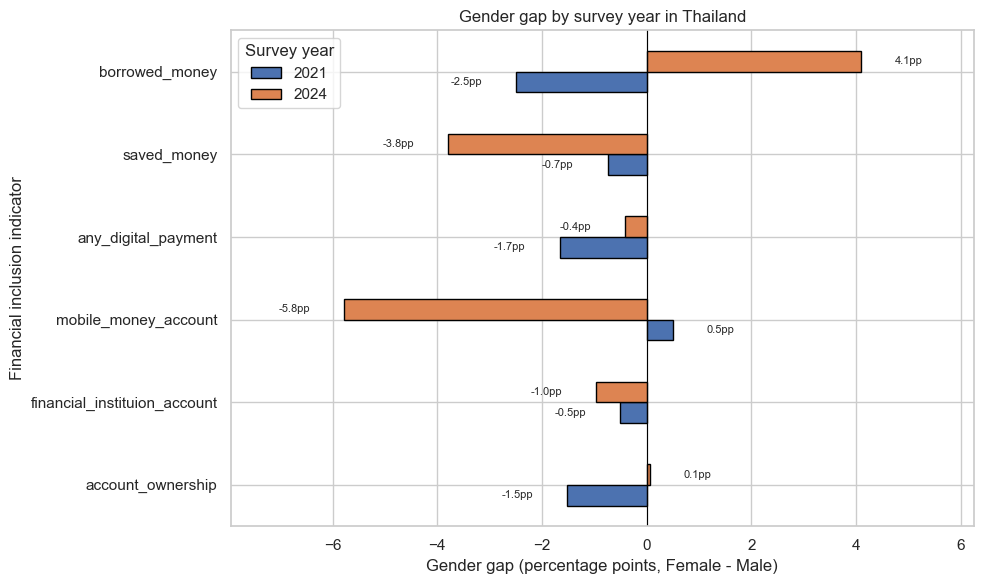

In [61]:
## Gender gap (Female - Male) by survey year, side by side
gap_by_year = (
    gender_year_inclusion.xs("Female", level="gender")
    - gender_year_inclusion.xs("Male", level="gender")
).T

ax = gap_by_year.plot(kind="barh", figsize=(10, 6), edgecolor="black")

buffer = max(gap_by_year.values.max(), abs(gap_by_year.values.min())) * 0.2 + 1
ax.set_xlim(gap_by_year.values.min() - buffer, gap_by_year.values.max() + buffer)
ax.margins(y=0.15)

for bar in ax.patches:
    value = bar.get_width()
    offset = buffer * 0.3 if value >= 0 else -buffer * 0.3
    ha = "left" if value >= 0 else "right"
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}pp", ha=ha, va="center", fontsize=8)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Gender gap (percentage points, Female - Male)")
plt.ylabel("Financial inclusion indicator")
plt.title("Gender gap by survey year in Thailand")
plt.legend(title="Survey year")

plt.subplots_adjust(left=0.3)
plt.tight_layout()
plt.show()


### F-Test 
age variability between male and female respondents.

In [63]:
from scipy.stats import levene 

male_age = rq3.loc[rq3["gender"] == "Male", "age"].dropna()
female_age = rq3.loc[rq3["gender"] == "Female", "age"].dropna()

stat, p = levene(male_age, female_age)
print("Levene test statistic:", stat)
print("Levene test p-value:", p)


print("Male age variance:", male_age.var())
print("Female age variance:", female_age.var())
print("Male age standard deviation:", male_age.std())
print("Female age standard deviation:", female_age.std())
print("Male age mean:", male_age.mean())
print("Female age mean:", female_age.mean())

Levene test statistic: 0.3273880883661586
Levene test p-value: 0.5672652846603048
Male age variance: 270.58579623000736
Female age variance: 262.26970204739865
Male age standard deviation: 16.44949227879108
Female age standard deviation: 16.194743037399473
Male age mean: 43.698237885462554
Female age mean: 45.24294813466788


### Chi-Square Test
Association between gender and account ownership.
- H0: Account ownership is independent of gender (no association)
- Ha: Account ownership is not independent of gender (there is an association)


In [64]:
from scipy.stats import chi2_contingency

# H0: account ownership is independent of gender (no association)
# Ha: account ownership is not independent of gender (there is an association)

contingency_table = pd.crosstab(rq3["gender"], rq3["account_ownership"])
print(contingency_table)

chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2_stat)
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("Expected frequencies:\n", expected)

alpha = 0.05
if p_value < alpha:
    print(f"\np-value ({p_value:.4f}) < alpha ({alpha}): reject H0 -> account ownership is associated with gender.")
else:
    print(f"\np-value ({p_value:.4f}) >= alpha ({alpha}): fail to reject H0 -> no evidence of association between account ownership and gender.")


account_ownership   0     1
gender                     
Female             63  1038
Male               41   875

Chi-square statistic: 1.3430053753386282
Degrees of freedom: 1
p-value: 0.24650465885437722
Expected frequencies:
 [[  56.76945959 1044.23054041]
 [  47.23054041  868.76945959]]

p-value (0.2465) >= alpha (0.05): fail to reject H0 -> no evidence of association between account ownership and gender.


### Chi-Square Test: Gender vs each financial inclusion indicator
- H0: The indicator is independent of gender (no association)
- Ha: The indicator is not independent of gender (there is an association)


In [65]:
alpha = 0.05
chi_square_results = []

for col in financial_vars:
    table = pd.crosstab(rq3["gender"], rq3[col])
    chi2_stat, p_value, dof, expected = chi2_contingency(table)
    chi_square_results.append({
        "variable": col,
        "chi2": chi2_stat,
        "dof": dof,
        "p_value": p_value,
        "significant": p_value < alpha
    })

    print(f"\n{col}")
    print(table)
    print(f"chi2 = {chi2_stat:.4f}, dof = {dof}, p-value = {p_value:.4f}")
    if p_value < alpha:
        print(f"p-value < alpha ({alpha}): reject H0 -> {col} is associated with gender.")
    else:
        print(f"p-value >= alpha ({alpha}): fail to reject H0 -> no evidence of association between {col} and gender.")

chi_square_summary = pd.DataFrame(chi_square_results).sort_values("p_value")
chi_square_summary



account_ownership
account_ownership   0     1
gender                     
Female             63  1038
Male               41   875
chi2 = 1.3430, dof = 1, p-value = 0.2465
p-value >= alpha (0.05): fail to reject H0 -> no evidence of association between account_ownership and gender.

financial_instituion_account
financial_instituion_account   0     1
gender                                
Female                        70  1031
Male                          47   869
chi2 = 1.1619, dof = 1, p-value = 0.2811
p-value >= alpha (0.05): fail to reject H0 -> no evidence of association between financial_instituion_account and gender.

mobile_money_account
mobile_money_account  0.0  1.0
gender                        
Female                560  541
Male                  416  500
chi2 = 5.7263, dof = 1, p-value = 0.0167
p-value < alpha (0.05): reject H0 -> mobile_money_account is associated with gender.

any_digital_payment
any_digital_payment  0.0  1.0
gender                       
Female         

,variable,chi2,dof,p_value,significant
2,mobile_money_account,5.726272,1,0.016713,True
4,saved_money,3.310029,1,0.068858,False
3,any_digital_payment,2.302372,1,0.129177,False
0,account_ownership,1.343005,1,0.246505,False
1,financial_instituion_account,1.161942,1,0.281063,False
5,borrowed_money,0.131026,1,0.717371,False


### Chi-Square Test: Gender vs each financial inclusion indicator, by survey year
- H0: The indicator is independent of gender within that survey year (no association)
- Ha: The indicator is not independent of gender within that survey year (there is an association)


In [66]:
alpha = 0.05
chi_square_by_year_results = []

for year in sorted(rq3["survey_year"].unique()):
    year_data = rq3[rq3["survey_year"] == year]
    print(f"\n===== Survey year {year} =====")

    for col in financial_vars:
        table = pd.crosstab(year_data["gender"], year_data[col])
        chi2_stat, p_value, dof, expected = chi2_contingency(table)
        chi_square_by_year_results.append({
            "survey_year": year,
            "variable": col,
            "chi2": chi2_stat,
            "dof": dof,
            "p_value": p_value,
            "significant": p_value < alpha
        })

        print(f"\n{col} ({year})")
        print(table)
        print(f"chi2 = {chi2_stat:.4f}, dof = {dof}, p-value = {p_value:.4f}")
        if p_value < alpha:
            print(f"p-value < alpha ({alpha}): reject H0 -> {col} is associated with gender in {year}.")
        else:
            print(f"p-value >= alpha ({alpha}): fail to reject H0 -> no evidence of association between {col} and gender in {year}.")

chi_square_by_year_summary = (
    pd.DataFrame(chi_square_by_year_results)
    .sort_values(["variable", "survey_year"])
    .reset_index(drop=True)
)
chi_square_by_year_summary


===== Survey year 2021 =====

account_ownership (2021)
account_ownership   0    1
gender                    
Female             14  502
Male                6  495
chi2 = 2.2935, dof = 1, p-value = 0.1299
p-value >= alpha (0.05): fail to reject H0 -> no evidence of association between account_ownership and gender in 2021.

financial_instituion_account (2021)
financial_instituion_account   0    1
gender                               
Female                        15  501
Male                          12  489
chi2 = 0.0976, dof = 1, p-value = 0.7547
p-value >= alpha (0.05): fail to reject H0 -> no evidence of association between financial_instituion_account and gender in 2021.

mobile_money_account (2021)
mobile_money_account  0.0  1.0
gender                        
Female                154  362
Male                  152  349
chi2 = 0.0107, dof = 1, p-value = 0.9176
p-value >= alpha (0.05): fail to reject H0 -> no evidence of association between mobile_money_account and gender in 2021.


,survey_year,variable,chi2,dof,p_value,significant
0,2021,account_ownership,2.293453,1,0.129921,False
1,2024,account_ownership,0.000000,1,1.000000,False
2,2021,any_digital_payment,1.558830,1,0.211837,False
3,2024,any_digital_payment,0.007296,1,0.931930,False
4,2021,borrowed_money,0.583337,1,0.445007,False
5,2024,borrowed_money,1.492707,1,0.221797,False
6,2021,financial_instituion_account,0.097638,1,0.754683,False
7,2024,financial_instituion_account,0.172130,1,0.678226,False
8,2021,mobile_money_account,0.010707,1,0.917587,False
9,2024,mobile_money_account,3.420471,1,0.064393,False


In [68]:
inclusion_score_vars = ["account_ownership", 
                        "financial_instituion_account",
                        "mobile_money_account",
                        "any_digital_payment",
                        "account_usage",
                        "saved_money",
                        "borrowed_money"] 

In [69]:
rq3["financial_inclusion_score"] = rq3[inclusion_score_vars].mean(axis=1)

In [70]:
# ANOVA financial inclusion scores
from scipy.stats import f_oneway

male_scores = rq3.loc[rq3["gender"] == "Male", "financial_inclusion_score"].dropna()
female_scores = rq3.loc[rq3["gender"] == "Female", "financial_inclusion_score"].dropna()

f_stat, p_value = f_oneway(male_scores, female_scores)

print("ANOVA results for financial inclusion scores by gender:")
print("F-statistic:", f_stat)
print("p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha}): reject H0 -> financial inclusion scores are associated with gender.")
else:
    print(f"p-value ({p_value:.4f}) >= alpha ({alpha}): fail to reject H0 -> no evidence of association between financial inclusion scores and gender.")

ANOVA results for financial inclusion scores by gender:
F-statistic: 2.7216192032288307
p-value: 0.0991534048198978
p-value (0.0992) >= alpha (0.05): fail to reject H0 -> no evidence of association between financial inclusion scores and gender.


In [71]:
# Test whether score differs across educational levels 
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('financial_inclusion_score ~ C(education_level)', data=rq3).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                        sum_sq      df          F        PR(>F)
C(education_level)    4.115920     2.0  38.660391  3.351201e-17
Residual            106.889335  2008.0        NaN           NaN


In [72]:
# Interpretation of the ANOVA result
alpha = 0.05
f_stat = anova_table.loc["C(education_level)", "F"]
p_value = anova_table.loc["C(education_level)", "PR(>F)"]

print("H0: Mean financial inclusion score is equal across all education levels")
print("Ha: At least one education level has a different mean financial inclusion score\n")
print(f"F-statistic = {f_stat:.4f}, p-value = {p_value:.4e}")

if p_value < alpha:
    print(f"p-value < alpha ({alpha}): reject H0 -> financial inclusion score differs significantly across education levels.")
else:
    print(f"p-value >= alpha ({alpha}): fail to reject H0 -> no evidence that financial inclusion score differs across education levels.")

print("\nMean financial inclusion score by education level:")
print(rq3.groupby("education_level")["financial_inclusion_score"].mean())

# Post-hoc pairwise comparison to see which specific levels differ
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=rq3["financial_inclusion_score"].dropna(),
    groups=rq3.loc[rq3["financial_inclusion_score"].notna(), "education_level"],
    alpha=alpha
)
print("\nTukey HSD post-hoc pairwise comparisons:")
print(tukey.summary())


H0: Mean financial inclusion score is equal across all education levels
Ha: At least one education level has a different mean financial inclusion score

F-statistic = 38.6604, p-value = 3.3512e-17
p-value < alpha (0.05): reject H0 -> financial inclusion score differs significantly across education levels.

Mean financial inclusion score by education level:
education_level
1.0    0.807929
2.0    0.894306
3.0     0.90287
Name: financial_inclusion_score, dtype: Float64

Tukey HSD post-hoc pairwise comparisons:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   1.0    2.0   0.0864    0.0  0.0536 0.1191   True
   1.0    3.0   0.0949    0.0  0.0636 0.1263   True
   1.0    nan  -0.0738 0.8636 -0.3171 0.1695  False
   2.0    3.0   0.0086 0.9252 -0.0269  0.044  False
   2.0    nan  -0.1602 0.3298  -0.404 0.0837  False
   3.0    nan  -0.1687  0.283 -0.4124 0.0749  False
-------------------

### Two-way ANOVA 

In [73]:
model_2way = ols("financial_inclusion_score ~ C(gender) * C(survey_year)", data=rq3).fit()
anova_table_2way = sm.stats.anova_lm(model_2way, typ=2)
print(anova_table_2way)

# Interpretation of the two-way ANOVA result
alpha = 0.05
for factor in ["C(gender)", "C(survey_year)", "C(gender):C(survey_year)"]:
    f_stat = anova_table_2way.loc[factor, "F"]
    p_value = anova_table_2way.loc[factor, "PR(>F)"]
    print(f"\nH0: No effect of {factor} on financial inclusion score")
    print(f"Ha: {factor} has a significant effect on financial inclusion score")
    print(f"F-statistic = {f_stat:.4f}, p-value = {p_value:.4e}")
    if p_value < alpha:
        print(f"p-value < alpha ({alpha}): reject H0 -> {factor} has a significant effect.")
    else:
        print(f"p-value >= alpha ({alpha}): fail to reject H0 -> no evidence that {factor} has a significant effect.")

                              sum_sq      df          F    PR(>F)
C(gender)                   0.089407     1.0   1.633159  0.201414
C(survey_year)              1.269633     1.0  23.191779  0.000002
C(gender):C(survey_year)    0.001054     1.0   0.019254  0.889654
Residual                  110.201623  2013.0        NaN       NaN

H0: No effect of C(gender) on financial inclusion score
Ha: C(gender) has a significant effect on financial inclusion score
F-statistic = 1.6332, p-value = 2.0141e-01
p-value >= alpha (0.05): fail to reject H0 -> no evidence that C(gender) has a significant effect.

H0: No effect of C(survey_year) on financial inclusion score
Ha: C(survey_year) has a significant effect on financial inclusion score
F-statistic = 23.1918, p-value = 1.5756e-06
p-value < alpha (0.05): reject H0 -> C(survey_year) has a significant effect.

H0: No effect of C(gender):C(survey_year) on financial inclusion score
Ha: C(gender):C(survey_year) has a significant effect on financial inclusi

### Logistic Regression

In [ ]:
# logistic regression Is gender associated with account ownership after controlling for age, education, income, employment and survey year? 

import statsmodels.api as sm
import statsmodels.formula.api as smf

# Fit the logistic regression model
model_logit = smf.logit("""
                        account_ownership
                        ~ C(gender)
                        + age
                        + C(education_level)
                        + C(income_quintile)
                        + C(employment_status)
                        + C(survey_year)""",
                        data=rq3).fit()
print(model_logit.summary()) 

Optimization terminated successfully.
         Current function value: 0.183475
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      account_ownership   No. Observations:                 2002
Model:                          Logit   Df Residuals:                     1991
Method:                           MLE   Df Model:                           10
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.09511
Time:                        21:29:34   Log-Likelihood:                -367.32
converged:                       True   LL-Null:                       -405.92
Covariance Type:            nonrobust   LLR p-value:                 1.764e-12
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            2.3965      0.448      5.34

In [78]:
# Interpretation of the logistic regression (odds ratios are easier to read than log-odds coefficients)
alpha = 0.05

# Categorical predictors are dummy-coded: each shown level is compared against a dropped
# reference level (here Female for gender), which is absorbed into the Intercept.
odds_ratios = np.exp(model_logit.params)
conf_int = np.exp(model_logit.conf_int())
summary_df = pd.DataFrame({
    "odds_ratio": odds_ratios,
    "ci_lower": conf_int[0],
    "ci_upper": conf_int[1],
    "p_value": model_logit.pvalues
}).drop("Intercept")

print("Odds ratios (exp(coef)) with 95% CI:")
print(summary_df.round(4))

print(f"\nModel fit: Pseudo R-squ. = {model_logit.prsquared:.4f}, LLR p-value = {model_logit.llr_pvalue:.4e}")
print("LLR p-value < alpha -> the model as a whole fits significantly better than an intercept-only model.\n"
      if model_logit.llr_pvalue < alpha else
      "LLR p-value >= alpha -> the model does not fit significantly better than an intercept-only model.\n")

print("Interpretation of significant predictors (p < 0.05):")
for var, row in summary_df.iterrows():
    if row["p_value"] < alpha:
        direction = "higher" if row["odds_ratio"] > 1 else "lower"
        pct_change = abs(row["odds_ratio"] - 1) * 100
        print(f"- {var}: OR = {row['odds_ratio']:.3f} (p={row['p_value']:.4f}) "
              f"-> {pct_change:.1f}% {direction} odds of account ownership vs. the reference group, holding other variables constant.")

print("\nNot significant (p >= 0.05) -> no evidence of an effect after controlling for the other variables:")
for var, row in summary_df.iterrows():
    if row["p_value"] >= alpha:
        print(f"- {var} (p={row['p_value']:.4f})")

print("\nKey takeaway: gender (C(gender)[T.Male]) is NOT statistically significant (p=0.443) after controlling for "
      "age, education, income, employment, and survey year -> no evidence that gender alone predicts account "
      "ownership once these other factors are accounted for. Education, income (Q2/Q4), employment status, "
      "survey year, and age are significant predictors.")

Odds ratios (exp(coef)) with 95% CI:
                                  odds_ratio  ci_lower  ci_upper  p_value
C(gender)[T.Male]                     1.1777    0.7756    1.7885   0.4428
C(education_level)[T.2.0]             2.3150    1.2829    4.1775   0.0053
C(education_level)[T.3.0]             2.0951    1.0104    4.3443   0.0468
C(income_quintile)[T.Q2]              2.8630    1.3642    6.0086   0.0054
C(income_quintile)[T.Q3]              1.3672    0.7408    2.5232   0.3171
C(income_quintile)[T.Q4]              2.0352    1.0442    3.9667   0.0369
C(income_quintile)[T.Q5 Highest]      1.4304    0.7832    2.6124   0.2441
C(employment_status)[T.2.0]           0.6011    0.3861    0.9359   0.0242
C(survey_year)[T.2024]                0.2987    0.1685    0.5297   0.0000
age                                   1.0139    1.0016    1.0264   0.0268

Model fit: Pseudo R-squ. = 0.0951, LLR p-value = 1.7638e-12
LLR p-value < alpha -> the model as a whole fits significantly better than an intercept-

In [79]:
# Interaction model 
model_logit_interaction = smf.logit(
    """
    account_ownership
    ~ female
    + C(survey_year)
    + female:C(survey_year)
    + age
    + C(education_level)
    + C(income_quintile)
    + C(employment_status)
    """,
    data=rq3
).fit()
print(model_logit_interaction.summary())


Optimization terminated successfully.
         Current function value: 0.182934
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      account_ownership   No. Observations:                 2002
Model:                          Logit   Df Residuals:                     1990
Method:                           MLE   Df Model:                           11
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.09777
Time:                        21:47:21   Log-Likelihood:                -366.23
converged:                       True   LL-Null:                       -405.92
Covariance Type:            nonrobust   LLR p-value:                 1.948e-12
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            1.3874      0.777      1.78

In [81]:
# Did the association between gender and account ownership change over survey years?
# Results from model_logit_interaction

alpha = 0.05
interaction_terms = ["female", "C(survey_year)[T.2024]", "female:C(survey_year)[T.2024]"]

interaction_summary = pd.DataFrame({
    "odds_ratio": np.exp(model_logit_interaction.params[interaction_terms]),
    "p_value": model_logit_interaction.pvalues[interaction_terms]
})
print(interaction_summary.round(4))

# Interpretation of the interaction model results
inter_p = model_logit_interaction.pvalues["female:C(survey_year)[T.2024]"]
female_p = model_logit_interaction.pvalues["female"]
year_p = model_logit_interaction.pvalues["C(survey_year)[T.2024]"]

print(f"\nH0: The gender effect on account ownership is the same in 2021 and 2024 (no interaction)")
print(f"Ha: The gender effect on account ownership differs between 2021 and 2024 (interaction present)")
print(f"female:C(survey_year)[T.2024] -> coef = {model_logit_interaction.params['female:C(survey_year)[T.2024]']:.4f}, "
      f"p-value = {inter_p:.4f}")

if inter_p < alpha:
    print(f"p-value < alpha ({alpha}): reject H0 -> the gender gap in account ownership changed significantly between 2021 and 2024.")
else:
    print(f"p-value >= alpha ({alpha}): fail to reject H0 -> no evidence that the gender gap in account ownership "
          f"changed between 2021 and 2024; the effect of gender does not significantly depend on survey year.")

print(f"\nMain effect 'female' (gender effect in the 2021 baseline year): p-value = {female_p:.4f} "
      f"-> {'significant' if female_p < alpha else 'not significant'} at alpha={alpha}.")
print(f"Main effect 'survey_year 2024' (year effect when female=0/Male): p-value = {year_p:.4f} "
      f"-> {'significant' if year_p < alpha else 'not significant'} at alpha={alpha}.")

print("\nKey takeaway: because the interaction term is not significant, there is no statistical evidence that the "
      "\ngender gap in account ownership widened or narrowed from 2021 to 2024, after controlling for age, education, "
      "\nincome, and employment status. Consistent with the earlier main-effects model, gender itself is also not a "
      "\nsignificant predictor of account ownership once these other factors are controlled for.")


                               odds_ratio  p_value
female                             2.2018   0.1104
C(survey_year)[T.2024]             0.8812   0.8717
female:C(survey_year)[T.2024]      0.4560   0.1517

H0: The gender effect on account ownership is the same in 2021 and 2024 (no interaction)
Ha: The gender effect on account ownership differs between 2021 and 2024 (interaction present)
female:C(survey_year)[T.2024] -> coef = -0.7852, p-value = 0.1517
p-value >= alpha (0.05): fail to reject H0 -> no evidence that the gender gap in account ownership changed between 2021 and 2024; the effect of gender does not significantly depend on survey year.

Main effect 'female' (gender effect in the 2021 baseline year): p-value = 0.1104 -> not significant at alpha=0.05.
Main effect 'survey_year 2024' (year effect when female=0/Male): p-value = 0.8717 -> not significant at alpha=0.05.

Key takeaway: because the interaction term is not significant, there is no statistical evidence that the 
gender ga

In [83]:
name_list = financial_vars 
name_list

['account_ownership',
 'financial_instituion_account',
 'mobile_money_account',
 'any_digital_payment',
 'saved_money',
 'borrowed_money']

In [82]:
for outcome in financial_vars:
    formula = f"""
        {outcome}
        ~ female
        + C(survey_year)
        + female:C(survey_year)
        + age
        + C(education_level)
        + C(income_quintile)
        + C(employment_status)
    """
    model = smf.logit(formula=formula, data=rq3).fit(disp=False) 
    print(f"Results for outcome variable: {outcome}")
    print(model.summary())

Results for outcome variable: account_ownership
                           Logit Regression Results                           
Dep. Variable:      account_ownership   No. Observations:                 2002
Model:                          Logit   Df Residuals:                     1990
Method:                           MLE   Df Model:                           11
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                 0.09777
Time:                        21:58:36   Log-Likelihood:                -366.23
converged:                       True   LL-Null:                       -405.92
Covariance Type:            nonrobust   LLR p-value:                 1.948e-12
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            1.3874      0.777      1.785      0.074      -0.136       2.911
C(survey_year)[T.

In [84]:
# Convert logistic coefficients to odds ratios 
import numpy as np 

odd_ratio = np.exp(model.params)
print(odd_ratio)

Intercept                           1.674229
C(survey_year)[T.2024]              1.038268
C(education_level)[T.2.0]           1.445411
C(education_level)[T.3.0]           1.935411
C(income_quintile)[T.Q2]            1.117016
C(income_quintile)[T.Q3]            0.988474
C(income_quintile)[T.Q4]            0.942654
C(income_quintile)[T.Q5 Highest]    1.138914
C(employment_status)[T.2.0]         0.476996
female                              1.077667
female:C(survey_year)[T.2024]       0.729234
age                                 0.990451
dtype: float64


In [86]:
# Add confidence interval 
import numpy as np
conf_int = model.conf_int()

results  = pd.DataFrame({
    "Odds_Ratio": odd_ratio,
    "CI_Lower": np.exp(conf_int[0]),
    "CI_Upper": np.exp(conf_int[1]),
    "P_Value": model.pvalues
})
print(results) 

                                  Odds_Ratio  CI_Lower  CI_Upper       P_Value
Intercept                           1.674229  0.953150  2.940820  7.296931e-02
C(survey_year)[T.2024]              1.038268  0.579363  1.860664  8.995991e-01
C(education_level)[T.2.0]           1.445411  1.136372  1.838492  2.685800e-03
C(education_level)[T.3.0]           1.935411  1.475051  2.539447  1.891974e-06
C(income_quintile)[T.Q2]            1.117016  0.804661  1.550620  5.084444e-01
C(income_quintile)[T.Q3]            0.988474  0.715320  1.365935  9.439915e-01
C(income_quintile)[T.Q4]            0.942654  0.688111  1.291357  7.130654e-01
C(income_quintile)[T.Q5 Highest]    1.138914  0.834354  1.554645  4.126173e-01
C(employment_status)[T.2.0]         0.476996  0.375707  0.605591  1.215239e-09
female                              1.077667  0.827450  1.403548  5.789756e-01
female:C(survey_year)[T.2024]       0.729234  0.502259  1.058783  9.697006e-02
age                                 0.990451  0.9843

### Marginal Effects

In [87]:
marginal_effects = model.get_margeff()
print(marginal_effects.summary())

        Logit Marginal Effects       
Dep. Variable:         borrowed_money
Method:                          dydx
At:                           overall
                                      dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
C(survey_year)[T.2024]               0.0085      0.067      0.126      0.900      -0.123       0.140
C(education_level)[T.2.0]            0.0832      0.027      3.028      0.002       0.029       0.137
C(education_level)[T.3.0]            0.1491      0.031      4.869      0.000       0.089       0.209
C(income_quintile)[T.Q2]             0.0250      0.038      0.662      0.508      -0.049       0.099
C(income_quintile)[T.Q3]            -0.0026      0.037     -0.070      0.944      -0.076       0.070
C(income_quintile)[T.Q4]            -0.0133      0.036     -0.368      0.713      -0.084       0.058
C(income_quintile)[T.Q5 Highest]     0.0

### Correlation Analysis

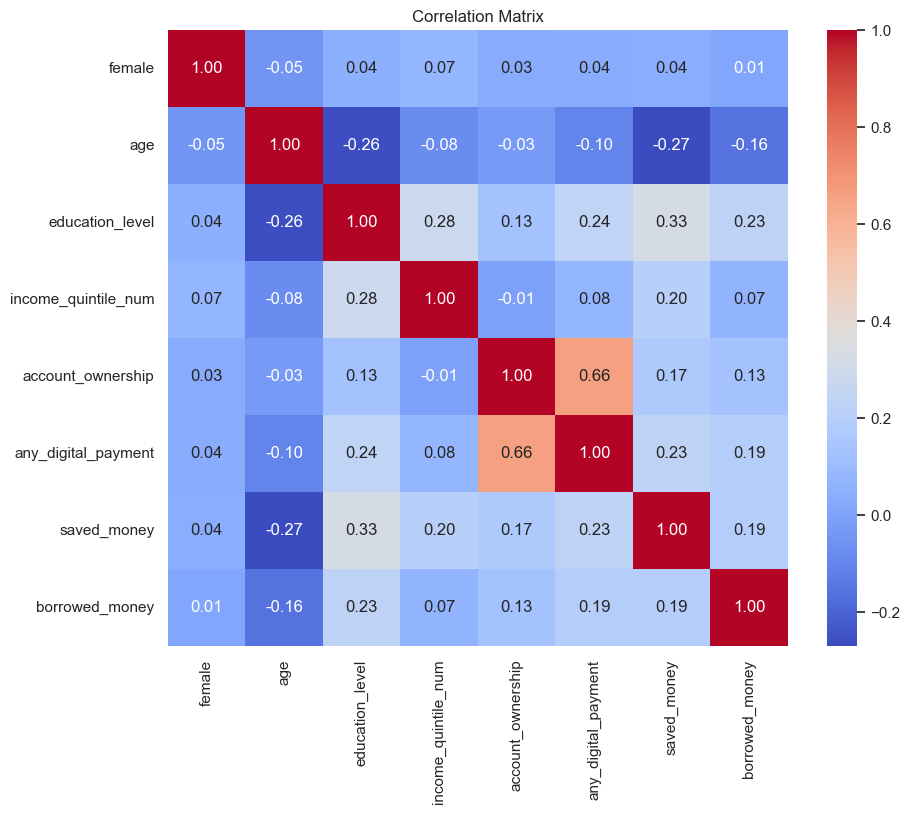

In [ ]:
corr_vars = [    
    "female",
    "age",
    "education_level",
    "income_quintile_num",
    "account_ownership",
    "any_digital_payment",
    "saved_money",
    "borrowed_money"]

# income_quintile is text (Q1..Q5 Highest) -> .corr() into a numeric column
income_quintile_map = {"Q1": 1, "Q2": 2, "Q3": 3, "Q4": 4, "Q5 Highest": 5}
rq3["income_quintile_num"] = rq3["income_quintile"].map(income_quintile_map)

corr_matrix = rq3[corr_vars].corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") 
plt.title("Correlation Matrix") 
plt.show()

### ML Models

In [92]:
y = rq3["account_ownership"] 
features  = [
    "age",
    "gender",
    "income_quintile",
    "education_level",
    "employment_status",
    "survey_year"
]

In [ ]:
X = pd.get_dummies(rq3[features], 
                columns=[
                    "gender",
                    "income_quintile",
                    "education_level", 
                    "employment_status", 
                    "survey_year"], drop_first=True) 
y = rq3["account_ownership"] 

Class balance in y (0 = no account, 1 = has account):
account_ownership
1    0.948181
0    0.051819
Name: proportion, dtype: float64

Accuracy: 0.5796019900497512
Balanced accuracy: 0.66572928383952

Classification report:
               precision    recall  f1-score   support

           0       0.09      0.76      0.16        21
           1       0.98      0.57      0.72       381

    accuracy                           0.58       402
   macro avg       0.53      0.67      0.44       402
weighted avg       0.93      0.58      0.69       402

Confusion matrix:
 [[ 16   5]
 [164 217]]

ROC-AUC: 0.7798400199975004

Odds ratios:
                       feature  coefficient  odds_ratio
2          income_quintile_Q2     1.001358    2.721975
7         education_level_3.0     0.854522    2.350250
6         education_level_2.0     0.768597    2.156739
4          income_quintile_Q4     0.578353    1.783099
3          income_quintile_Q3     0.339513    1.404263
5  income_quintile_Q5 Highest    

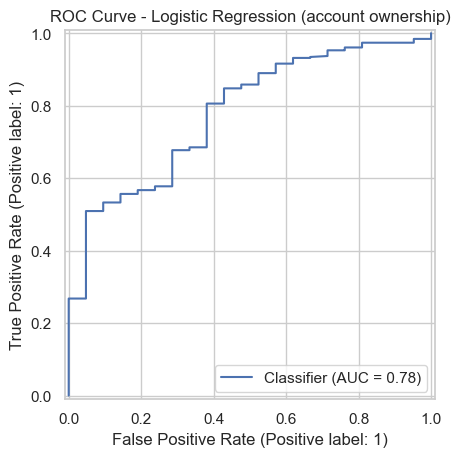

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)


data_model = pd.concat([X, y], axis=1).dropna()
X_clean = data_model[X.columns]
y_clean = data_model[y.name]

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

print("Class balance in y (0 = no account, 1 = has account):")
print(y_clean.value_counts(normalize=True))

# class_weight="balanced" upweights the minority class so the model doesn't just predict
# the majority class every time (which is what caused 0.00 precision/recall for class 0 above)
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

# Coefficients as odds ratios, matching the statsmodels-style interpretation used earlier
coef_summary = pd.DataFrame({
    "feature": X_clean.columns,
    "coefficient": log_reg.coef_[0],
    "odds_ratio": np.exp(log_reg.coef_[0])
}).sort_values("odds_ratio", ascending=False)
print("\nOdds ratios:\n", coef_summary)

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression (account ownership)")
plt.show()


### Random Forest Classifier

In [96]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]

print(
    "Random Forest AUC:",
    roc_auc_score(y_test, rf_prob)
)

Random Forest AUC: 0.7310336207974003


In [97]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

age                           0.352709
survey_year_2024              0.201546
education_level_3.0           0.087561
gender_Male                   0.065403
employment_status_2.0         0.064752
education_level_2.0           0.064583
income_quintile_Q2            0.046101
income_quintile_Q5 Highest    0.043612
income_quintile_Q3            0.038842
income_quintile_Q4            0.034892
dtype: float64


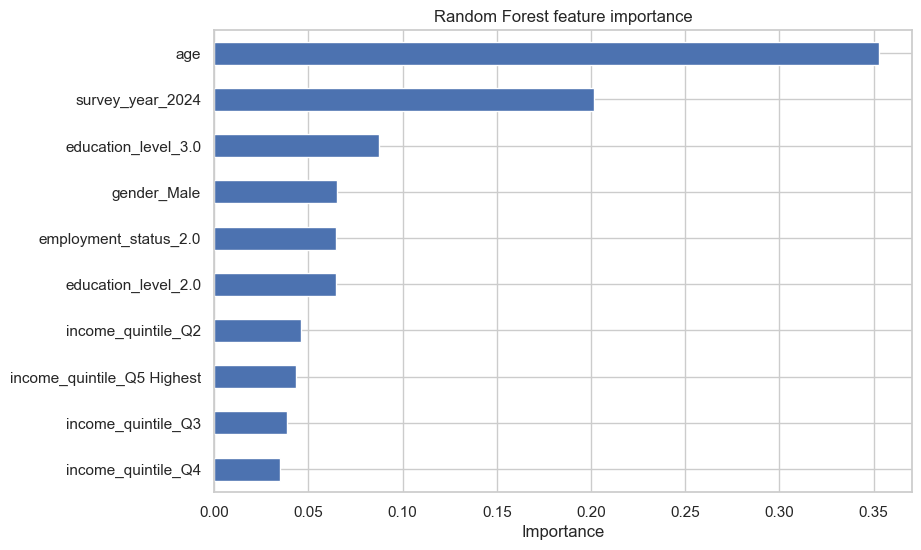

In [98]:
importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Importance")
plt.title("Random Forest feature importance")

plt.show()

In [99]:
# Multivariate (multi-label) ML model: predict several financial inclusion outcomes at once
from sklearn.multioutput import MultiOutputClassifier

target_vars = [
    "financial_instituion_account",
    "any_digital_payment",
    "saved_money",
    "borrowed_money"
]

# reuse the same feature set X built earlier (age, gender, income_quintile, education_level, employment_status, survey_year)
Y_multi = rq3[target_vars]

multi_data = pd.concat([X, Y_multi], axis=1).dropna()
X_multi = multi_data[X.columns]
Y_multi_clean = multi_data[target_vars]

X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(
    X_multi, Y_multi_clean, test_size=0.2, random_state=42
)

print("Class balance per target (share = 1):")
print(Y_multi_clean.mean())

multi_log_reg = MultiOutputClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
multi_log_reg.fit(X_train_m, Y_train_m)

Y_pred_m = pd.DataFrame(multi_log_reg.predict(X_test_m), columns=target_vars, index=X_test_m.index)
Y_prob_m = pd.DataFrame(
    np.column_stack([est.predict_proba(X_test_m)[:, 1] for est in multi_log_reg.estimators_]),
    columns=target_vars, index=X_test_m.index
)


Class balance per target (share = 1):
financial_instituion_account    0.941704
any_digital_payment             0.887892
saved_money                     0.680120
borrowed_money                  0.540608
dtype: float64


In [101]:
# Per-outcome evaluation of the multivariate model
eval_rows = []

for outcome in target_vars:
    y_true = Y_test_m[outcome]
    y_pred = Y_pred_m[outcome]
    y_prob = Y_prob_m[outcome]

    print(f"\n===== {outcome} =====")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

    eval_rows.append({
        "outcome": outcome,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    })

multi_eval_summary = pd.DataFrame(eval_rows)
print("\nSummary across outcomes:")
multi_eval_summary



===== financial_instituion_account =====
              precision    recall  f1-score   support

           0       0.11      0.72      0.19        25
           1       0.97      0.62      0.76       377

    accuracy                           0.62       402
   macro avg       0.54      0.67      0.47       402
weighted avg       0.92      0.62      0.72       402

Confusion matrix:
 [[ 18   7]
 [144 233]]

===== any_digital_payment =====
              precision    recall  f1-score   support

         0.0       0.25      0.80      0.38        49
         1.0       0.96      0.67      0.79       353

    accuracy                           0.68       402
   macro avg       0.60      0.73      0.58       402
weighted avg       0.87      0.68      0.74       402

Confusion matrix:
 [[ 39  10]
 [118 235]]

===== saved_money =====
              precision    recall  f1-score   support

         0.0       0.54      0.65      0.59       139
         1.0       0.80      0.71      0.75       263

,outcome,accuracy,balanced_accuracy,roc_auc
0,financial_instituion_account,0.624378,0.669019,0.719894
1,any_digital_payment,0.681592,0.730820,0.747239
2,saved_money,0.691542,0.682851,0.747914
3,borrowed_money,0.641791,0.642039,0.685755


### Multivariate Random Forest (same 4 outcomes)


In [102]:
multi_rf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
)
multi_rf.fit(X_train_m, Y_train_m)

rf_eval_rows = []
for i, outcome in enumerate(target_vars):
    y_true = Y_test_m[outcome]
    y_prob = multi_rf.estimators_[i].predict_proba(X_test_m)[:, 1]
    y_pred = multi_rf.estimators_[i].predict(X_test_m)

    rf_eval_rows.append({
        "outcome": outcome,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob)
    })

multi_rf_eval_summary = pd.DataFrame(rf_eval_rows)
print("Random Forest vs Logistic Regression (ROC-AUC per outcome):")
comparison = multi_eval_summary.merge(
    multi_rf_eval_summary, on="outcome", suffixes=("_logit", "_rf")
)
comparison


Random Forest vs Logistic Regression (ROC-AUC per outcome):


,outcome,accuracy_logit,balanced_accuracy_logit,roc_auc_logit,accuracy_rf,balanced_accuracy_rf,roc_auc_rf
0,financial_instituion_account,0.624378,0.669019,0.719894,0.778607,0.545836,0.692679
1,any_digital_payment,0.681592,0.730820,0.747239,0.713930,0.670145,0.742210
2,saved_money,0.691542,0.682851,0.747914,0.661692,0.654950,0.723623
3,borrowed_money,0.641791,0.642039,0.685755,0.634328,0.633393,0.677483
